In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [3]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


In [4]:
df = pd.read_csv('insurance.csv')

In [5]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [7]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
print(df.shape)

(1337, 7)


In [10]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [11]:
X = df.drop('charges', axis=1)

y = df['charges']

print(X.head())

print(y.head())

   age  sex     bmi  children  smoker  region
0   19    0  27.900         0       1       3
1   18    1  33.770         1       0       2
2   28    1  33.000         3       0       2
3   33    1  22.705         0       0       1
4   32    1  28.880         0       0       1
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
lr_model = LinearRegression()

In [14]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred_lr = lr_model.predict(X_test)

In [16]:
lr_accuracy = r2_score(y_test, y_pred_lr)

In [17]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print("R2 Score:", lr_accuracy)

print("Accuracy Percentage:", lr_accuracy * 100)

print("MAE:", mae_lr)

print("MSE:", mse_lr)

print("RMSE:", rmse_lr)

R2 Score: 0.8068466322629111
Accuracy Percentage: 80.68466322629111
MAE: 4182.353155288297
MSE: 35493102.61165053
RMSE: 5957.60879981646


In [18]:
poly = PolynomialFeatures(degree=2)

In [19]:
X_train_poly = poly.fit_transform(X_train)

In [20]:
X_test_poly = poly.transform(X_test)

In [21]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
poly_accuracy = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
print("R2 Score:", poly_accuracy)

print("Accuracy Percentage:", poly_accuracy * 100)

print("MAE:", mae_poly)

print("MSE:", mse_poly)

print("RMSE:", rmse_poly)

R2 Score: 0.8866092062012375
Accuracy Percentage: 88.66092062012375
MAE: 2844.9928829894593
MSE: 20836245.966956493
RMSE: 4564.67369775283


In [22]:

print("Linear Regression Accuracy : ", lr_accuracy * 100)

print("Polynomial Regression Accuracy : ", poly_accuracy * 100)

if poly_accuracy > lr_accuracy:
    print("\nPolynomial Regression gives better accuracy")
else:
    print("\nLinear Regression gives better accuracy")

Linear Regression Accuracy :  80.68466322629111
Polynomial Regression Accuracy :  88.66092062012375

Polynomial Regression gives better accuracy


In [23]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [24]:
!pip install xgboost

In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [26]:
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("R2 Score :", r2)

print("Accuracy Percentage :", r2 * 100)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

R2 Score : 0.8823985710662794
Accuracy Percentage : 88.23985710662794
MAE : 2756.156261918931
MSE : 21609975.706469554
RMSE : 4648.653106704086


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

from sklearn.metrics import r2_score

accuracy = r2_score(y_test, y_pred)

print("Accuracy :", accuracy * 100)

Accuracy : 89.50344787866786


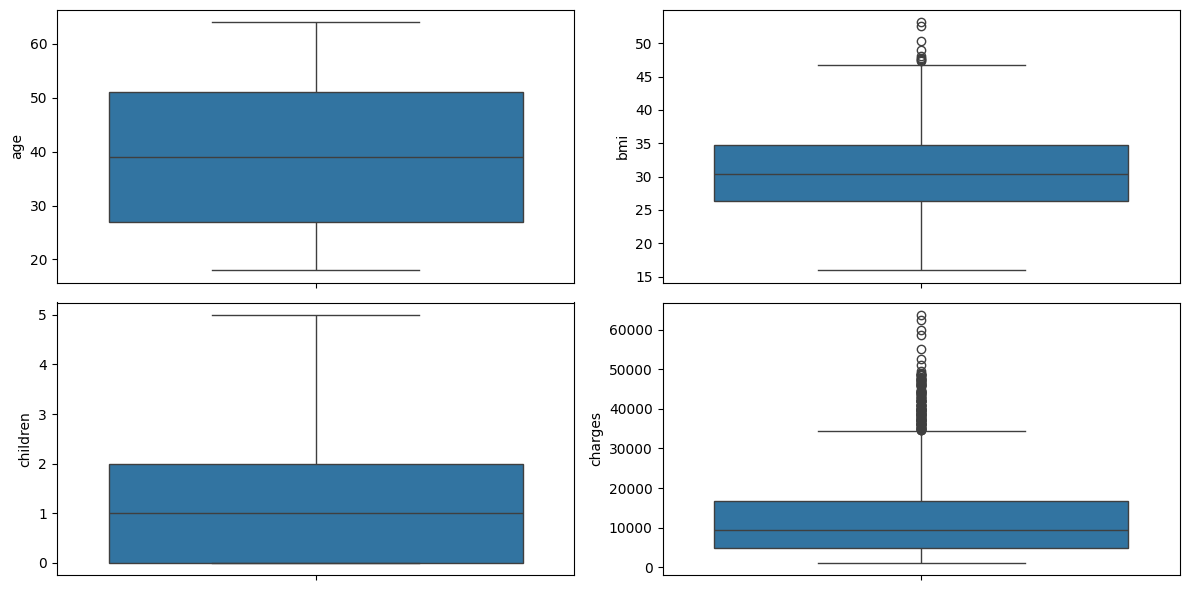

In [28]:
#check outlier
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [29]:
#remove outlier
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['charges'] >= lower) & (df['charges'] <= upper)]

print(df.shape)

(1198, 7)


In [30]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

        age       sex       bmi  children    smoker    region
0 -1.440418 -1.009771 -0.453160 -0.909234  1.969660  1.343163
1 -1.511647  0.990324  0.509422 -0.079442 -0.507702  0.438017
2 -0.799350  0.990324  0.383155  1.580143 -0.507702  0.438017
3 -0.443201  0.990324 -1.305052 -0.909234 -0.507702 -0.467128
4 -0.514431  0.990324 -0.292456 -0.909234 -0.507702 -0.467128


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

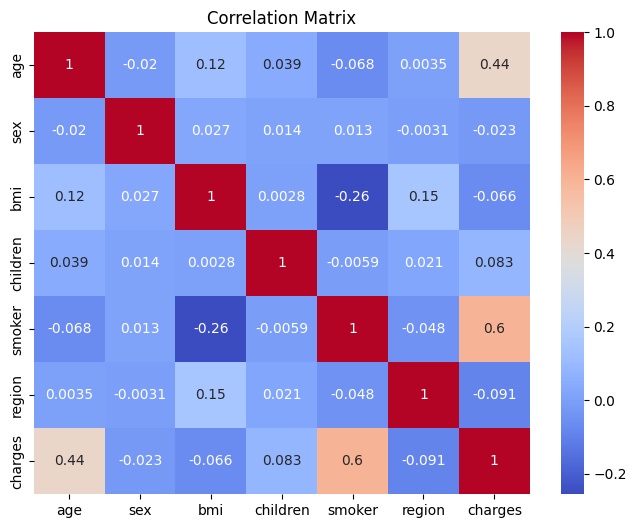

In [32]:
#correlation matrix 
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

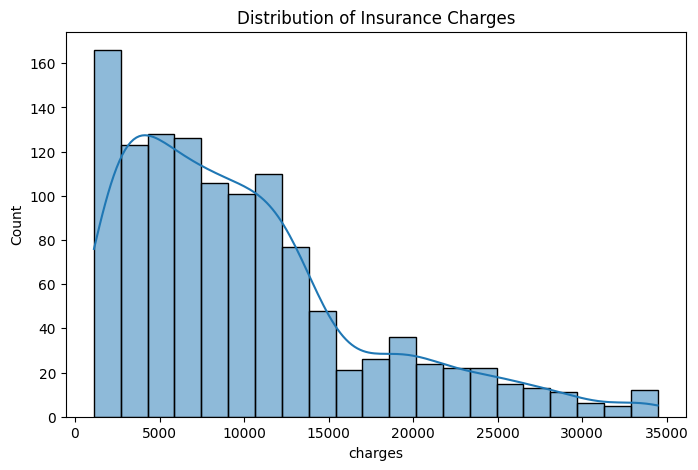

In [33]:
#Distribution of charges
plt.figure(figsize=(8,5))

sns.histplot(df['charges'], kde=True)

plt.title("Distribution of Insurance Charges")
plt.show()

<Figure size 1000x600 with 0 Axes>

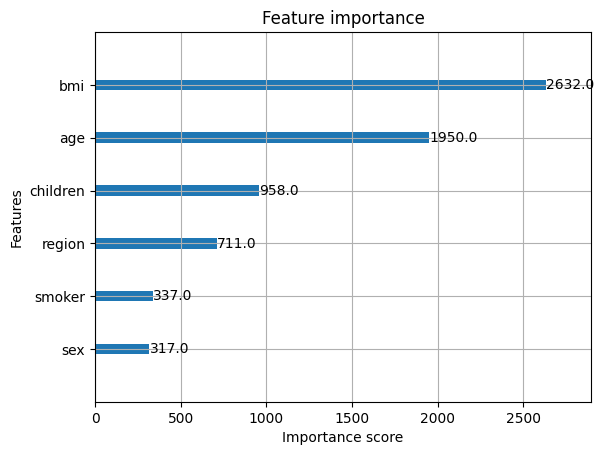

In [34]:
#check feature importance
from xgboost import plot_importance

plt.figure(figsize=(10,6))

plot_importance(xgb_model)

plt.show()

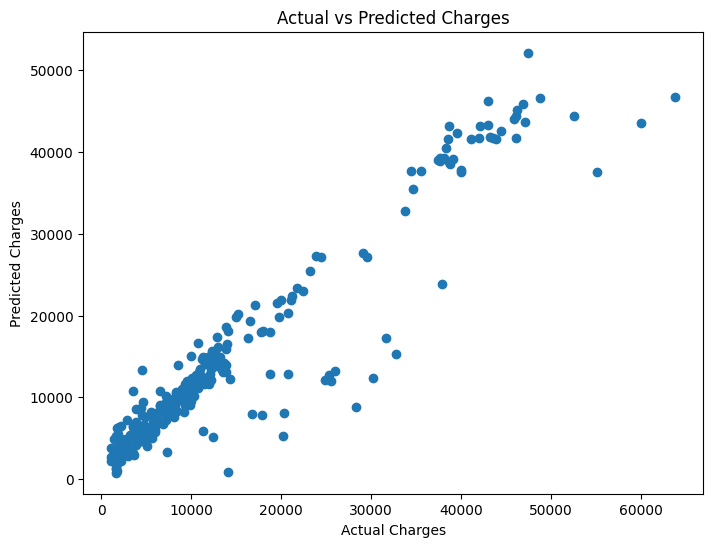

In [35]:
#Actual vs Predicted Plot 
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

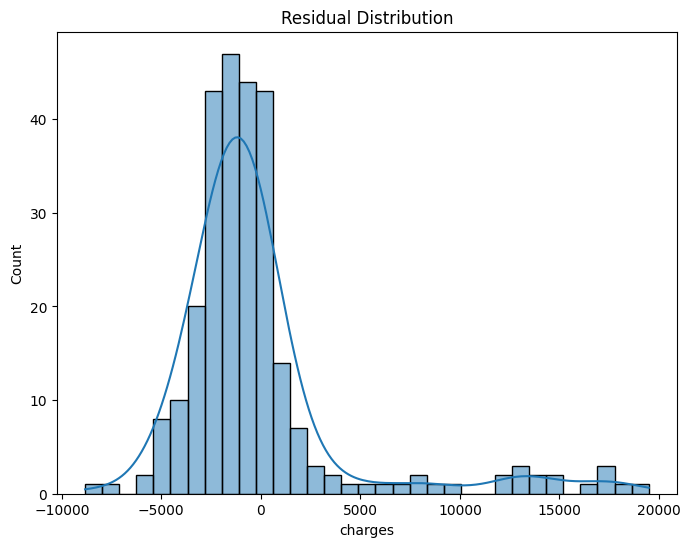

In [36]:
#Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [37]:
print(type(y_test))
print(type(y_pred))

print(y_test[:5])
print(y_pred[:5])

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
900      8688.85885
1064     5708.86700
1256    11436.73815
298     38746.35510
237      4463.20510
Name: charges, dtype: float64
[10516.613   7790.526  14595.295  38534.1     4610.1133]


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2644.7344060857918
MSE: 19288051.03818247
RMSE: 4391.816371182027
R2 Score: 0.8950344787866785


In [39]:
import joblib

joblib.dump(xgb_model, "insurance_model.pkl")

['insurance_model.pkl']